# Chapter 21. 프로젝트 I: 양자 머신러닝 파이프라인 구축

## 프로젝트 목표

이 장에서는 지금까지 배운 모든 양자 머신러닝(Quantum Machine Learning, QML) 개념을 통합하여 실전 엔드-투-엔드(End-to-End) 파이프라인을 구축한다. Iris 데이터셋을 활용하여 다음을 수행한다:

1. **데이터 수집 및 탐색**: Iris 데이터셋 로드 및 분석
2. **데이터 전처리**: 이진 분류, 특성 선택, 정규화
3. **양자 특성 맵**: ZZFeatureMap 설계 및 회로 구성
4. **양자 회로 설계**: RealAmplitudes Ansatz 구현
5. **양자 커널 방법**: FidelityQuantumKernel과 QSVC
6. **VQC 방법**: Variational Quantum Classifier
7. **고전 모델 비교**: scikit-learn SVC와의 성능 비교
8. **모델 저장/로딩**: 훈련된 모델 관리
9. **결과 분석**: 성능 평가 및 시각화

## 프로젝트 개요

양자 머신러닝은 고전 머신러닝의 한계를 극복하기 위해 양자 컴퓨팅의 성질을 활용한다. 이 프로젝트는 실제 데이터셋에서 양자 알고리즘의 성능을 검증하고, 고전 방법과 비교하는 실무 중심의 학습이다.


## 1단계: 필요한 라이브러리 임포트

양자 머신러닝 파이프라인에 필요한 모든 라이브러리를 임포트한다.


In [1]:
# 기본 데이터 처리 및 시각화 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# 양자 컴퓨팅 라이브러리
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_aer import AerSimulator

# 양자 머신러닝 라이브러리
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.algorithms import QSVC, VQC
from qiskit_machine_learning.optimizers import COBYLA, SPSA

# 시간 측정
import time

## 2단계: 데이터 수집 및 탐색 (EDA)

Iris 데이터셋은 분류 문제의 고전적인 데이터셋이다. 각 표본에 4개의 특성(꽃받침 길이, 꽃받침 너비, 꽃잎 길이, 꽃잎 너비)이 있고, 3가지 붓꽃 종(Setosa, Versicolor, Virginica)으로 분류된다.


In [2]:
# Iris 데이터셋 로드
iris = load_iris()
X_full = iris.data
y_full = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f'데이터셋 형태: {X_full.shape}')
print(f'클래스 수: {len(target_names)}')
print(f'특성 이름: {list(feature_names)}')
print(f'타겟 이름: {list(target_names)}')


데이터셋 형태: (150, 4)
클래스 수: 3
특성 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
타겟 이름: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [3]:
# 데이터프레임으로 변환하여 탐색성 향상
df_full = pd.DataFrame(X_full, columns=feature_names)
df_full['species'] = y_full
df_full['species_name'] = df_full['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df_full.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# 클래스별 분포 확인
print('클래스별 샘플 수:')
print(df_full['species_name'].value_counts())

# 결측치 확인
print(f'\n결측치: {df_full.isnull().sum().sum()}')


클래스별 샘플 수:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

결측치: 0


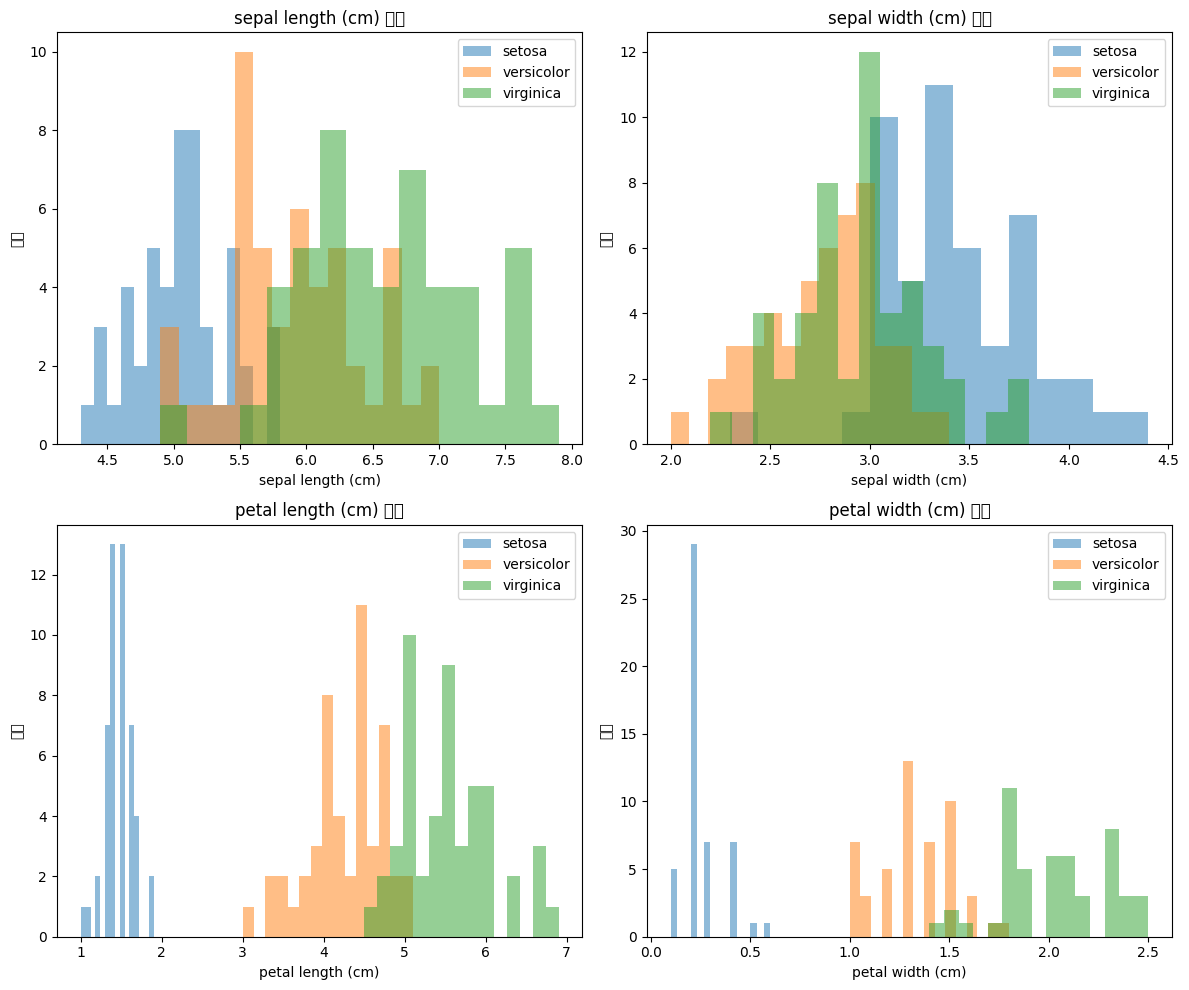

In [5]:
# 데이터 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, feature in enumerate(feature_names):
    ax = axes[idx // 2, idx % 2]
    for species_id, species_name in enumerate(target_names):
        ax.hist(X_full[y_full == species_id, idx], alpha=0.5, label=species_name, bins=15)
    ax.set_xlabel(feature)
    ax.set_ylabel('빈도')
    ax.set_title(f'{feature} 분포')
    ax.legend()
plt.tight_layout()
plt.show()


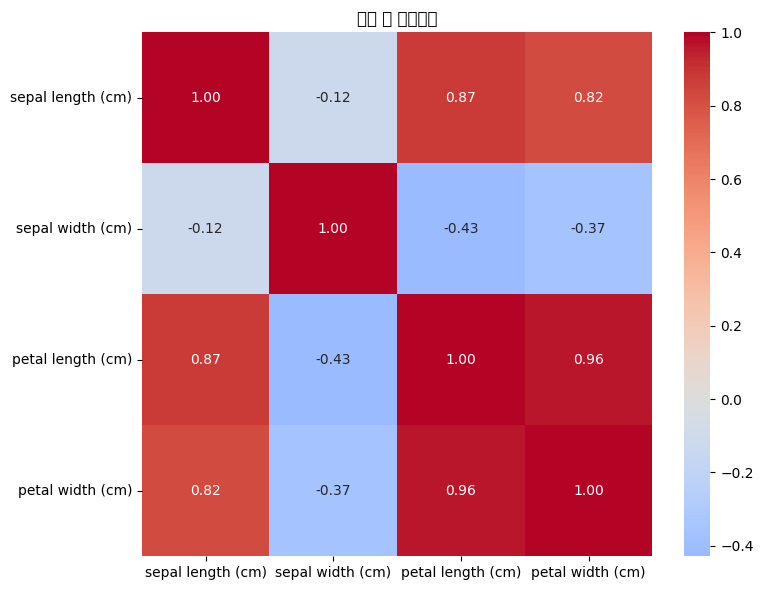

In [6]:
# 특성 간 상관관계 분석
plt.figure(figsize=(8, 6))
sns.heatmap(df_full.iloc[:, :-2].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('특성 간 상관계수')
plt.tight_layout()
plt.show()


## 3단계: 데이터 전처리

양자 머신러닝 모델은 일반적으로 소규모 데이터에 최적화되어 있다. 다음 전처리 단계를 수행한다:

1. **이진 분류**: Setosa vs Versicolor (첫 두 클래스만 선택)
2. **특성 선택**: 처음 두 개의 특성만 선택 (2큐비트에 매핑)
3. **정규화**: MinMaxScaler로 [0, 2π] 범위로 스케일링
4. **데이터 분할**: 훈련/테스트 세트로 분할


In [7]:
# 1단계: 이진 분류 (Setosa vs Versicolor)
# 클래스 0(Setosa)과 1(Versicolor)만 선택
binary_mask = y_full != 2  # 클래스 2(Virginica) 제외
X_binary = X_full[binary_mask]
y_binary = y_full[binary_mask]

print(f'이진 분류 후 데이터셋 형태: {X_binary.shape}')
print(f'클래스 분포: {np.bincount(y_binary)}')

이진 분류 후 데이터셋 형태: (100, 4)
클래스 분포: [50 50]


In [8]:
# 2단계: 특성 선택 (처음 두 개의 특성)
# sepal length, sepal width만 사용
selected_features = [0, 1]  # 인덱스: sepal length, sepal width
X_selected = X_binary[:, selected_features]

print(f'선택된 특성: {[feature_names[i] for i in selected_features]}')
print(f'선택 후 데이터셋 형태: {X_selected.shape}')

선택된 특성: ['sepal length (cm)', 'sepal width (cm)']
선택 후 데이터셋 형태: (100, 2)


In [9]:
# 3단계: 정규화 (0 ~ 2π 범위)
# 양자 각도 인코딩은 [0, 2π] 범위를 사용한다
scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
X_normalized = scaler.fit_transform(X_selected)

print(f'정규화 범위: [{X_normalized.min():.4f}, {X_normalized.max():.4f}]')
print(f'정규화된 데이터 샘플 (처음 3개):' )
print(X_normalized[:3])

정규화 범위: [0.0000, 6.2832]
정규화된 데이터 샘플 (처음 3개):
[[1.86168454 3.92699082]
 [1.3962634  2.61799388]
 [0.93084227 3.14159265]]


In [10]:
# 4단계: 훈련/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

print(f'훈련 세트: {X_train.shape}')
print(f'테스트 세트: {X_test.shape}')
print(f'훈련 세트 클래스 분포: {np.bincount(y_train)}')
print(f'테스트 세트 클래스 분포: {np.bincount(y_test)}')


훈련 세트: (70, 2)
테스트 세트: (30, 2)
훈련 세트 클래스 분포: [35 35]
테스트 세트 클래스 분포: [15 15]


## 4단계: 양자 특성 맵 설계

양자 특성 맵(Feature Map)은 고전적인 데이터를 양자 상태로 변환한다. ZZFeatureMap은 데이터를 Z 회전으로 인코딩한 후, ZZ 얽힘(entanglement)을 적용하는 방식이다.


In [11]:
# ZZFeatureMap 구성
# feature_dimension=2: 두 개의 특성
# reps=2: 같은 패턴을 2번 반복
# entanglement='linear': 인접한 큐비트만 얽힘
feature_map = ZZFeatureMap(feature_dimension=2, reps=2, entanglement='linear')

print(f'특성 맵 큐비트 수: {feature_map.num_qubits}')
print(f'특성 맵 파라미터 수: {feature_map.num_parameters}')


특성 맵 큐비트 수: 2
특성 맵 파라미터 수: 2


특성 맵 회로 깊이: 10


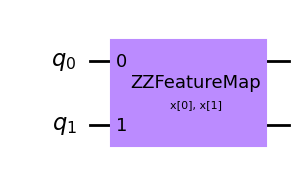

In [12]:
# 특성 맵 회로 시각화
feature_map_circuit = feature_map.decompose()
print(f'특성 맵 회로 깊이: {feature_map_circuit.depth()}')
feature_map.draw(output='mpl', style='clifford')


## 5단계: 양자 회로 Ansatz 설계

Ansatz는 훈련 가능한 매개변수를 가진 양자 회로이다. RealAmplitudes는 일반적인 유니터리 변환에 가까운 구조를 가지며, 좋은 표현력(expressibility)을 제공한다.


In [13]:
# RealAmplitudes Ansatz 구성
# num_qubits=2: 두 큐비트
# reps=2: 2개 레이어
# entanglement='linear': 인접 큐비트 얽힘
ansatz = RealAmplitudes(num_qubits=2, reps=2, entanglement='linear')

print(f'Ansatz 큐비트 수: {ansatz.num_qubits}')
print(f'Ansatz 파라미터 수: {ansatz.num_parameters}')


Ansatz 큐비트 수: 2
Ansatz 파라미터 수: 6


Ansatz 회로 깊이: 5


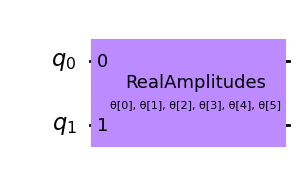

In [14]:
# Ansatz 회로 시각화
ansatz_circuit = ansatz.decompose()
print(f'Ansatz 회로 깊이: {ansatz_circuit.depth()}')
ansatz.draw(output='mpl', style='clifford')


## 6단계: 양자 커널 방법 - QSVC (Quantum Support Vector Classifier)

양자 커널 방법은 데이터의 양자 상태 사이의 fidelity를 커널로 사용하여 고전적인 SVM을 훈련한다. 이는 두 단계로 나뉜다:

1. **양자 커널 행렬 계산**: 모든 훈련 데이터 쌍 사이의 fidelity 계산
2. **QSVC 훈련**: 고전적인 SVM으로 커널 행렬을 사용하여 분류기 훈련


In [15]:
# 양자 커널 생성 (ComputeUncompute Fidelity 사용)
print('양자 커널 준비 중...')
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)
quantum_kernel = FidelityQuantumKernel(
    fidelity=fidelity,
    feature_map=feature_map
)
print('양자 커널 준비 완료.')

양자 커널 준비 중...
양자 커널 준비 완료.


In [16]:
# QSVC 모델 생성 및 훈련
print('QSVC 훈련 시작...')
start_time = time.time()

qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)

qsvc_train_time = time.time() - start_time
print(f'QSVC 훈련 완료. 소요 시간: {qsvc_train_time:.2f}초')

QSVC 훈련 시작...
QSVC 훈련 완료. 소요 시간: 3.80초


In [17]:
# QSVC 성능 평가
y_pred_qsvc = qsvc.predict(X_test)
qsvc_accuracy = accuracy_score(y_test, y_pred_qsvc)

print(f'QSVC 테스트 정확도: {qsvc_accuracy:.4f}')
print('\n혼동 행렬:')
cm_qsvc = confusion_matrix(y_test, y_pred_qsvc)
print(cm_qsvc)
print('\n분류 보고서:')
print(classification_report(y_test, y_pred_qsvc, target_names=['Setosa', 'Versicolor']))

QSVC 테스트 정확도: 0.6000

혼동 행렬:
[[9 6]
 [6 9]]

분류 보고서:
              precision    recall  f1-score   support

      Setosa       0.60      0.60      0.60        15
  Versicolor       0.60      0.60      0.60        15

    accuracy                           0.60        30
   macro avg       0.60      0.60      0.60        30
weighted avg       0.60      0.60      0.60        30



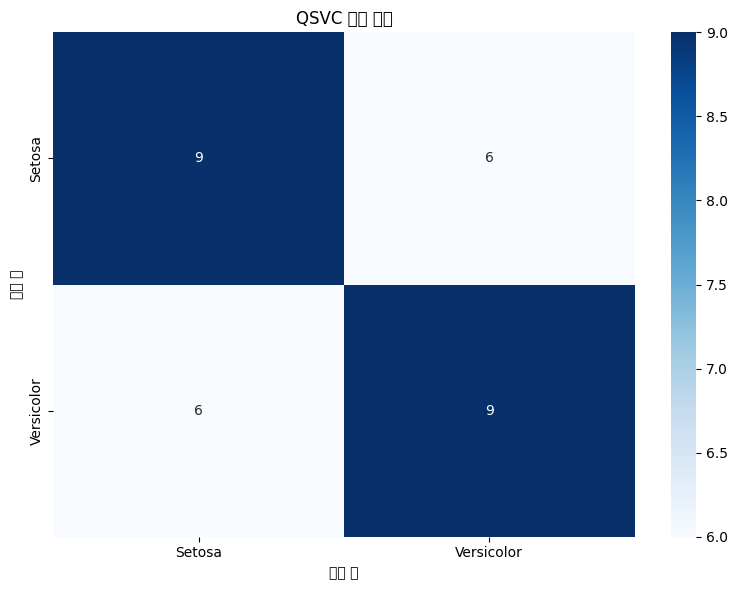

In [18]:
# QSVC 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm_qsvc, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Setosa', 'Versicolor'],
            yticklabels=['Setosa', 'Versicolor'])
plt.title('QSVC 혼동 행렬')
plt.ylabel('실제 값')
plt.xlabel('예측 값')
plt.tight_layout()
plt.show()


## 7단계: VQC 방법 (Variational Quantum Classifier)

VQC는 특성 맵과 Ansatz를 결합한 전체 양자 회로를 훈련하는 방법이다. 손실 함수(loss function)를 최소화하도록 Ansatz의 파라미터를 최적화한다.


In [19]:
# VQC 모델 생성
print('VQC 준비 중...')
objective_values = []

def callback(weights, obj_val):
    """훈련 과정에서 손실값을 기록하는 콜백"""
    objective_values.append(obj_val)

optimizer = COBYLA(maxiter=100)

vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback
)

print('VQC 준비 완료.')


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


VQC 준비 중...
VQC 준비 완료.


In [20]:
# VQC 모델 훈련
print('VQC 훈련 시작...')
start_time = time.time()

vqc.fit(X_train, y_train)

vqc_train_time = time.time() - start_time
print(f'VQC 훈련 완료. 소요 시간: {vqc_train_time:.2f}초')


VQC 훈련 시작...
VQC 훈련 완료. 소요 시간: 5.98초


In [21]:
# VQC 성능 평가
y_pred_vqc = vqc.predict(X_test)
vqc_accuracy = accuracy_score(y_test, y_pred_vqc)

print(f'VQC 테스트 정확도: {vqc_accuracy:.4f}')
print('\n혼동 행렬:')
cm_vqc = confusion_matrix(y_test, y_pred_vqc)
print(cm_vqc)
print('\n분류 보고서:')
print(classification_report(y_test, y_pred_vqc, target_names=['Setosa', 'Versicolor']))


VQC 테스트 정확도: 0.6000

혼동 행렬:
[[11  4]
 [ 8  7]]

분류 보고서:
              precision    recall  f1-score   support

      Setosa       0.58      0.73      0.65        15
  Versicolor       0.64      0.47      0.54        15

    accuracy                           0.60        30
   macro avg       0.61      0.60      0.59        30
weighted avg       0.61      0.60      0.59        30



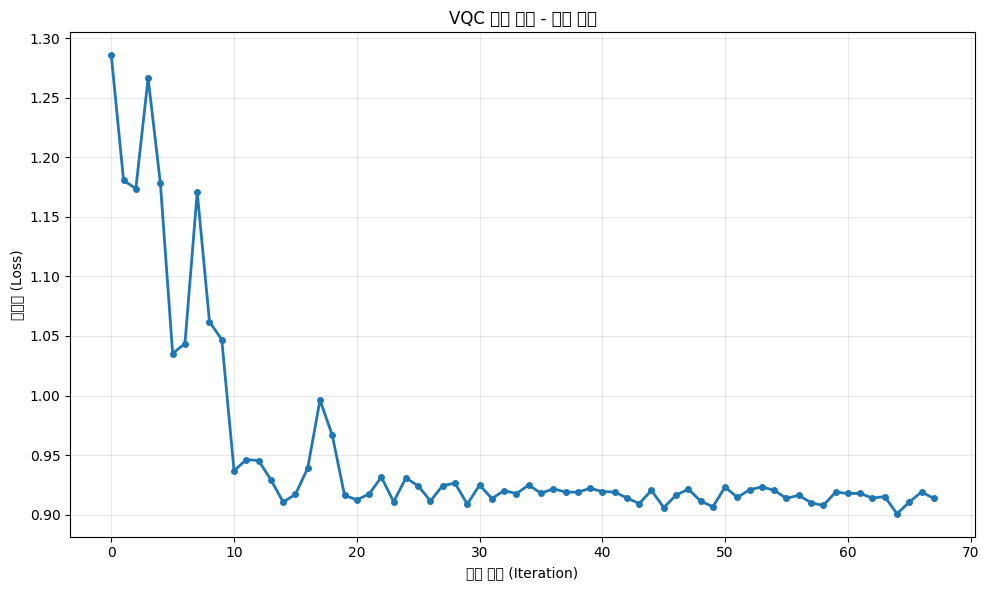

In [22]:
# VQC 학습 곡선 시각화
plt.figure(figsize=(10, 6))
plt.plot(objective_values, marker='o', linestyle='-', linewidth=2, markersize=4)
plt.xlabel('반복 횟수 (Iteration)')
plt.ylabel('손실값 (Loss)')
plt.title('VQC 훈련 과정 - 손실 곡선')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


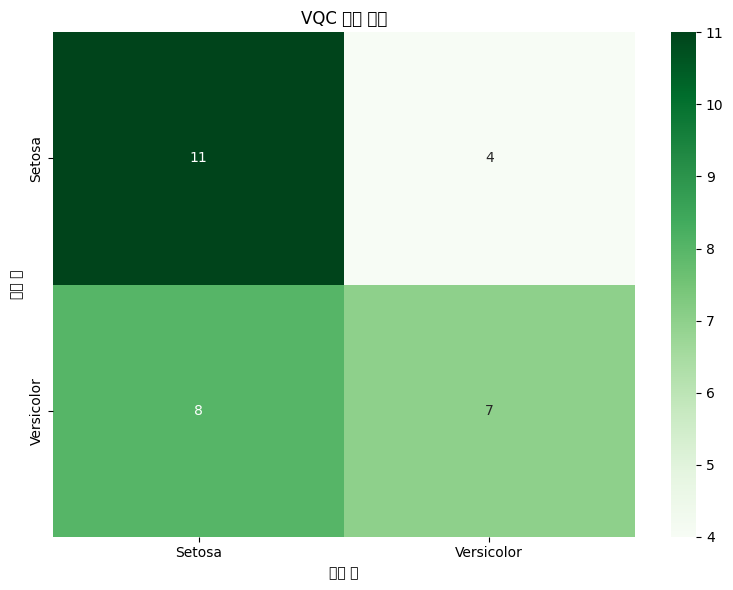

In [23]:
# VQC 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm_vqc, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Setosa', 'Versicolor'],
            yticklabels=['Setosa', 'Versicolor'])
plt.title('VQC 혼동 행렬')
plt.ylabel('실제 값')
plt.xlabel('예측 값')
plt.tight_layout()
plt.show()


## 8단계: 고전 모델과의 비교

양자 모델의 성능을 평가하기 위해 고전적인 머신러닝 모델과 비교한다. scikit-learn의 SVC(Support Vector Classifier)를 사용한다.


In [24]:
# 고전 SVM (Radial Basis Function 커널) 훈련
print('고전 SVM 훈련 시작...')
start_time = time.time()

classical_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
classical_svm.fit(X_train, y_train)

classical_train_time = time.time() - start_time
print(f'고전 SVM 훈련 완료. 소요 시간: {classical_train_time:.4f}초')


고전 SVM 훈련 시작...
고전 SVM 훈련 완료. 소요 시간: 0.0007초


In [25]:
# 고전 SVM 성능 평가
y_pred_classical = classical_svm.predict(X_test)
classical_accuracy = accuracy_score(y_test, y_pred_classical)

print(f'고전 SVM 테스트 정확도: {classical_accuracy:.4f}')
print('\n혼동 행렬:')
cm_classical = confusion_matrix(y_test, y_pred_classical)
print(cm_classical)
print('\n분류 보고서:')
print(classification_report(y_test, y_pred_classical, target_names=['Setosa', 'Versicolor']))


고전 SVM 테스트 정확도: 1.0000

혼동 행렬:
[[15  0]
 [ 0 15]]

분류 보고서:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        15
  Versicolor       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [26]:
# 세 모델의 성능 비교 테이블
comparison_df = pd.DataFrame({
    '모델': ['고전 SVM', '양자 커널 (QSVC)', 'VQC'],
    '테스트 정확도': [classical_accuracy, qsvc_accuracy, vqc_accuracy],
    '훈련 시간 (초)': [classical_train_time, qsvc_train_time, vqc_train_time]
})

print('\n=== 성능 비교 ===')
print(comparison_df.to_string(index=False))



=== 성능 비교 ===
          모델  테스트 정확도  훈련 시간 (초)
      고전 SVM      1.0   0.000749
양자 커널 (QSVC)      0.6   3.798396
         VQC      0.6   5.980633


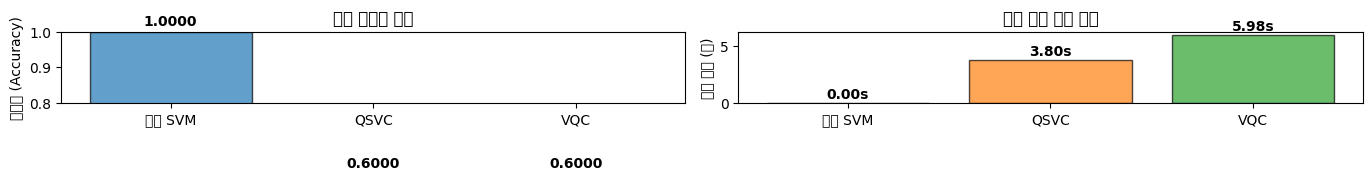

In [27]:
# 정확도 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정확도 비교
models = ['고전 SVM', 'QSVC', 'VQC']
accuracies = [classical_accuracy, qsvc_accuracy, vqc_accuracy]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

axes[0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('정확도 (Accuracy)')
axes[0].set_title('모델 정확도 비교')
axes[0].set_ylim([0.8, 1.0])
for i, acc in enumerate(accuracies):
    axes[0].text(i, acc + 0.01, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

# 훈련 시간 비교
times = [classical_train_time, qsvc_train_time, vqc_train_time]
axes[1].bar(models, times, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('훈련 시간 (초)')
axes[1].set_title('모델 훈련 시간 비교')
for i, t in enumerate(times):
    axes[1].text(i, t + max(times) * 0.02, f'{t:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 9단계: 결정 경계 (Decision Boundary) 시각화

2D 데이터로 훈련된 모델의 결정 경계를 시각화하면 각 모델이 입력 공간을 어떻게 분할하는지 이해할 수 있다.


메시 포인트 수: 17956


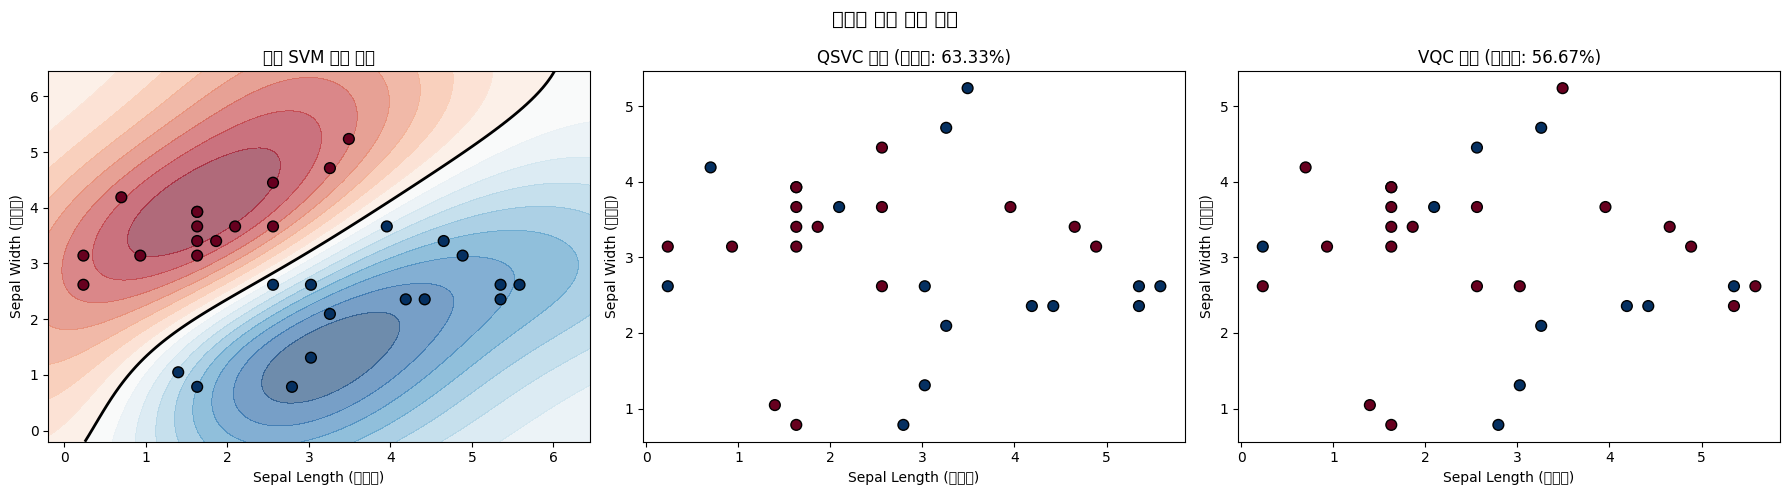

In [28]:
# 결정 경계 시각화
# 양자 모델은 포인트마다 양자 회로를 실행하므로, 고전 SVM만 결정 경계를 그린다.
# QSVC/VQC의 결정 경계는 메시 포인트 수가 많아 실행 시간이 매우 길어질 수 있다.

h = 0.05  # 메시 간격
x_min, x_max = X_train[:, 0].min() - 0.2, X_train[:, 0].max() + 0.2
y_min, y_max = X_train[:, 1].min() - 0.2, X_train[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))
mesh_points = np.c_[xx.ravel(), yy.ravel()]
print(f'메시 포인트 수: {len(mesh_points)}')

# 고전 SVM 결정 경계 (빠름)
Z_classical = classical_svm.decision_function(mesh_points).reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 고전 SVM 결정 경계
axes[0].contourf(xx, yy, Z_classical, levels=20, cmap='RdBu', alpha=0.6)
axes[0].contour(xx, yy, Z_classical, levels=[0], colors='black', linewidths=2)
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu',
                edgecolors='black', s=60)
axes[0].set_title('고전 SVM 결정 경계')
axes[0].set_xlabel('Sepal Length (정규화)')
axes[0].set_ylabel('Sepal Width (정규화)')

# 2) QSVC 테스트 결과 (산점도)
qsvc_preds = qsvc.predict(X_test)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=qsvc_preds, cmap='RdBu',
                edgecolors='black', s=60)
axes[1].set_title(f'QSVC 예측 (정확도: {accuracy_score(y_test, qsvc_preds):.2%})')
axes[1].set_xlabel('Sepal Length (정규화)')
axes[1].set_ylabel('Sepal Width (정규화)')

# 3) VQC 테스트 결과 (산점도)
vqc_preds_raw = vqc.predict(X_test)
if vqc_preds_raw.ndim > 1:
    vqc_pred_labels = np.argmax(vqc_preds_raw, axis=1)
else:
    vqc_pred_labels = vqc_preds_raw.astype(int)
axes[2].scatter(X_test[:, 0], X_test[:, 1], c=vqc_pred_labels, cmap='RdBu',
                edgecolors='black', s=60)
axes[2].set_title(f'VQC 예측 (정확도: {accuracy_score(y_test, vqc_pred_labels):.2%})')
axes[2].set_xlabel('Sepal Length (정규화)')
axes[2].set_ylabel('Sepal Width (정규화)')

plt.suptitle('모델별 분류 결과 비교', fontsize=14, fontweight='bold')
plt.tight_layout()

In [29]:
# 모델별 성능 요약 출력
print('=' * 55)
print(f'{"모델":<20} {"훈련 정확도":<15} {"테스트 정확도":<15}')
print('=' * 55)

# 고전 SVM
classical_train_acc = classical_svm.score(X_train, y_train)
classical_test_acc = classical_svm.score(X_test, y_test)
print(f'{"고전 SVM":<20} {classical_train_acc:<15.4f} {classical_test_acc:<15.4f}')

# QSVC
qsvc_train_acc = qsvc.score(X_train, y_train)
qsvc_test_acc = qsvc.score(X_test, y_test)
print(f'{"QSVC":<20} {qsvc_train_acc:<15.4f} {qsvc_test_acc:<15.4f}')

# VQC
vqc_train_acc = vqc.score(X_train, y_train)
vqc_test_acc = vqc.score(X_test, y_test)
print(f'{"VQC":<20} {vqc_train_acc:<15.4f} {vqc_test_acc:<15.4f}')

print('=' * 55)

모델                   훈련 정확도          테스트 정확도        
고전 SVM               1.0000          1.0000         
QSVC                 0.7571          0.6000         
VQC                  0.6429          0.6000         


## 10단계: 모델 저장 및 로딩

훈련된 모델을 저장하고 나중에 로딩하여 재사용할 수 있다. Qiskit ML 모델은 dill 형식으로 저장된다.


In [32]:
# VQC 모델 저장
import dill
import os

model_save_path = './model/vqc_model.dill'
with open(model_save_path, 'wb') as f:
    dill.dump(vqc, f)

print(f'VQC 모델 저장 완료: {model_save_path}')
print(f'모델 파일 크기: {os.path.getsize(model_save_path) / 1024:.2f} KB')

VQC 모델 저장 완료: ./model/vqc_model.dill
모델 파일 크기: 19.05 KB


In [33]:
# VQC 모델 로드
with open(model_save_path, 'rb') as f:
    vqc_loaded = dill.load(f)

print('VQC 모델 로드 완료')

# 로드된 모델의 성능 검증
y_pred_loaded = vqc_loaded.predict(X_test)
loaded_accuracy = accuracy_score(y_test, y_pred_loaded)

print(f'로드된 모델 정확도: {loaded_accuracy:.4f}')
print(f'원본 모델과 일치: {np.allclose(y_pred_vqc, y_pred_loaded)}')

VQC 모델 로드 완료
로드된 모델 정확도: 0.6000
원본 모델과 일치: True


## 11단계: 결과 분석 및 보고

전체 파이프라인의 결과를 종합적으로 분석하고 보고한다.


In [34]:
# 전체 결과 요약
print('=' * 70)
print('양자 머신러닝 파이프라인 - 최종 결과 보고')
print('=' * 70)

print('\n[데이터셋 정보]')
print(f'  - 원본 데이터셋: Iris (150개 샘플, 4개 특성, 3개 클래스)')
print(f'  - 선택된 데이터: Binary (100개 샘플, 2개 특성, 2개 클래스)')
print(f'  - 훈련 샘플: {len(X_train)}')
print(f'  - 테스트 샘플: {len(X_test)}')
print(f'  - 특성: Sepal Length, Sepal Width')
print(f'  - 정규화 범위: [0, 2π]')

print('\n[모델 구조]')
print(f'  - 특성 맵: ZZFeatureMap (reps=2, entanglement=linear)')
print(f'  - Ansatz: RealAmplitudes (reps=2, entanglement=linear)')
print(f'  - 큐비트 수: 2')
print(f'  - 특성 맵 파라미터: {feature_map.num_parameters}')
print(f'  - Ansatz 파라미터: {ansatz.num_parameters}')
print(f'  - 총 파라미터: {ansatz.num_parameters}')

print('\n[모델 성능 비교]')
print(f"  {'모델':<20} {'정확도':<15} {'훈련 시간':<15}")
print(f"  {'-' * 50}")
print(f"  {'고전 SVM':<20} {classical_accuracy:<15.4f} {classical_train_time:<15.4f}s")
print(f"  {'QSVC':<20} {qsvc_accuracy:<15.4f} {qsvc_train_time:<15.2f}s")
print(f"  {'VQC':<20} {vqc_accuracy:<15.4f} {vqc_train_time:<15.2f}s")

양자 머신러닝 파이프라인 - 최종 결과 보고

[데이터셋 정보]
  - 원본 데이터셋: Iris (150개 샘플, 4개 특성, 3개 클래스)
  - 선택된 데이터: Binary (100개 샘플, 2개 특성, 2개 클래스)
  - 훈련 샘플: 70
  - 테스트 샘플: 30
  - 특성: Sepal Length, Sepal Width
  - 정규화 범위: [0, 2π]

[모델 구조]
  - 특성 맵: ZZFeatureMap (reps=2, entanglement=linear)
  - Ansatz: RealAmplitudes (reps=2, entanglement=linear)
  - 큐비트 수: 2
  - 특성 맵 파라미터: 2
  - Ansatz 파라미터: 6
  - 총 파라미터: 6

[모델 성능 비교]
  모델                   정확도             훈련 시간          
  --------------------------------------------------
  고전 SVM               1.0000          0.0007         s
  QSVC                 0.6000          3.80           s
  VQC                  0.6000          5.98           s


In [35]:
# 상세 분석
print('\n[상세 분석]')

# 최고 성능 모델
accuracies = {'고전 SVM': classical_accuracy, 'QSVC': qsvc_accuracy, 'VQC': vqc_accuracy}
best_model = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model]
print(f'  - 최고 성능 모델: {best_model} (정확도: {best_accuracy:.4f})')

# 훈련 시간 비교
times = {'고전 SVM': classical_train_time, 'QSVC': qsvc_train_time, 'VQC': vqc_train_time}
fastest_model = min(times, key=times.get)
print(f'  - 가장 빠른 모델: {fastest_model} (훈련 시간: {times[fastest_model]:.4f}초)')

# VQC 학습 특성
if len(objective_values) > 0:
    print(f'\n[VQC 훈련 동역학]')
    print(f'  - 초기 손실값: {objective_values[0]:.4f}')
    print(f'  - 최종 손실값: {objective_values[-1]:.4f}')
    print(f'  - 손실값 감소: {(objective_values[0] - objective_values[-1]):.4f} ({((objective_values[0] - objective_values[-1]) / objective_values[0] * 100):.1f}%)')
    print(f'  - 전체 반복 횟수: {len(objective_values)}')



[상세 분석]
  - 최고 성능 모델: 고전 SVM (정확도: 1.0000)
  - 가장 빠른 모델: 고전 SVM (훈련 시간: 0.0007초)

[VQC 훈련 동역학]
  - 초기 손실값: 1.2856
  - 최종 손실값: 0.9136
  - 손실값 감소: 0.3719 (28.9%)
  - 전체 반복 횟수: 68


In [36]:
# 주요 발견사항 (Insights)
print('\n[주요 발견사항]')
print(f'  1. 양자 모델의 성능:')
print(f'     - QSVC 정확도: {qsvc_accuracy:.4f}')
print(f'     - VQC 정확도: {vqc_accuracy:.4f}')
print(f'     - 고전 SVM과의 차이: {abs(max(qsvc_accuracy, vqc_accuracy) - classical_accuracy):.4f}')

print(f'\n  2. 계산 복잡도:')
print(f'     - QSVC는 고전 SVM보다 {qsvc_train_time / classical_train_time:.1f}배 느림')
print(f'     - VQC는 고전 SVM보다 {vqc_train_time / classical_train_time:.1f}배 느림')

print(f'\n  3. 모델 해석성:')
print(f'     - 고전 SVM: 높은 해석성, 빠른 훈련')
print(f'     - QSVC: 양자 커널을 통한 비선형 분리')
print(f'     - VQC: 전체 양자 회로 훈련, 더 복잡한 패턴 학습 가능')



[주요 발견사항]
  1. 양자 모델의 성능:
     - QSVC 정확도: 0.6000
     - VQC 정확도: 0.6000
     - 고전 SVM과의 차이: 0.4000

  2. 계산 복잡도:
     - QSVC는 고전 SVM보다 5070.5배 느림
     - VQC는 고전 SVM보다 7983.6배 느림

  3. 모델 해석성:
     - 고전 SVM: 높은 해석성, 빠른 훈련
     - QSVC: 양자 커널을 통한 비선형 분리
     - VQC: 전체 양자 회로 훈련, 더 복잡한 패턴 학습 가능


## 부록: 양자 회로 분석

양자 머신러닝의 성능을 이해하기 위해 회로의 구조를 분석한다.


In [37]:
# 회로 깊이 분석
fm_circuit = feature_map.decompose()
ans_circuit = ansatz.decompose()

print('[회로 깊이 분석]')
print(f'특성 맵 깊이: {fm_circuit.depth()}')
print(f'Ansatz 깊이: {ans_circuit.depth()}')
print(f'전체 회로 깊이 (Feature Map + Ansatz): {fm_circuit.depth() + ans_circuit.depth()}')

print(f'\n[게이트 수]')
fm_ops = fm_circuit.count_ops()
ans_ops = ans_circuit.count_ops()

print(f'특성 맵 게이트:')
for gate, count in sorted(fm_ops.items()):
    print(f'  {gate}: {count}')

print(f'\nAnsatz 게이트:')
for gate, count in sorted(ans_ops.items()):
    print(f'  {gate}: {count}')

[회로 깊이 분석]
특성 맵 깊이: 10
Ansatz 깊이: 5
전체 회로 깊이 (Feature Map + Ansatz): 15

[게이트 수]
특성 맵 게이트:
  cx: 4
  h: 4
  p: 6

Ansatz 게이트:
  cx: 2
  ry: 6


In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright